# Unidad 3: Búsqueda, Optimización y Agentes Inteligentes
## 🎲 Búsqueda Local — Hill Climbing, Simulated Annealing, Algoritmos Genéticos
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/search/04_BusquedaLocal.ipynb)

---

### 🎯 Objetivos
- Comprender la metáfora del **paisaje de aptitud** (fitness landscape) y los óptimos locales.
- Aplicar **Hill Climbing** y diagnosticar por qué queda atrapado.
- Usar **Simulated Annealing** para escapar de óptimos locales.
- Implementar un **Algoritmo Genético** con `simpleai`.
- Comparar el rendimiento de todos los métodos sobre el problema de las **N-Reinas**.

---

### 📖 Teoría

En los problemas de **búsqueda local** no interesa el camino sino el **estado final** óptimo.
Se trabaja sobre un espacio de estados con una función objetivo $f(s)$ que se quiere **maximizar**.

| Algoritmo | Estrategia | Problema principal |
|-----------|------------|--------------------|
| Hill Climbing | Siempre sube | Queda en óptimos locales |
| HC + Reinicios Aleatorios | Múltiples intentos | Costo de múltiples reinicios |
| Simulated Annealing | Acepta peores soluciones con probabilidad $e^{-\Delta/T}$ | Ajuste del calendario de temperatura |
| Algoritmo Genético | Evolución de una población | Diseño del operador de cruce |

**Problema: N-Reinas (8 reinas)**

Colocar $N$ reinas en un tablero $N\times N$ de forma que ninguna se ataque.

- **Estado**: tupla de $N$ enteros, donde `estado[i]` = columna de la reina en la fila $i$.
- **Función de valor**: número de pares de reinas que **no** se atacan (maximizar).  
  Máximo = $\binom{N}{2} = \frac{N(N-1)}{2}$. Para $N=8$: **28 pares**.
- Una solución perfecta tiene valor **28**.

## 📦 Paso 1: Importaciones

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from simpleai.search import (
    SearchProblem,
    hill_climbing,
    hill_climbing_random_restarts,
    hill_climbing_stochastic,
    simulated_annealing,
    genetic,
)

random.seed(42)
np.random.seed(42)
print("✅ simpleai y librerías cargados")

✅ simpleai y librerías cargados


## ♟️ Paso 2: Definición del problema N-Reinas

La clase `NQueensProblem` extiende `SearchProblem` de `simpleai` e implementa:
- `generate_random_state()` — para reinicios aleatorios y algoritmo genético
- `value(state)` — función objetivo a maximizar
- `actions(state)` / `result(state, action)` — espacio de vecinos
- `crossover(s1, s2)` / `mutate(s)` — operadores genéticos

Estado aleatorio: (1, 0, 4, 3, 3, 2, 1, 1)
Valor (pares no atacantes): 18 / 28


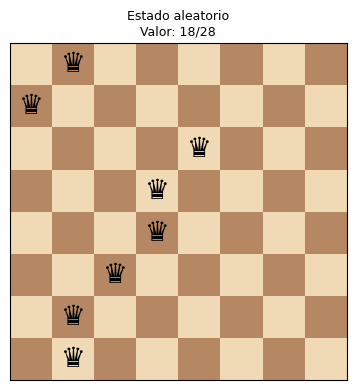

In [3]:
N = 8  # número de reinas
MAX_VALUE = N * (N - 1) // 2  # 28 para N=8


class NQueensProblem(SearchProblem):
    """
    Problema de N-Reinas para búsqueda local con simpleai.
    Estado: tupla de N enteros, estado[i] = columna de la reina en la fila i.
    """

    def generate_random_state(self):
        return tuple(random.randint(0, N - 1) for _ in range(N))

    def value(self, state):
        """Número de pares NO atacantes (0 a 28). Se maximiza."""
        attacks = 0
        for i in range(N):
            for j in range(i + 1, N):
                if state[i] == state[j]:                       # misma columna
                    attacks += 1
                elif abs(state[i] - state[j]) == abs(i - j):  # diagonal
                    attacks += 1
        return MAX_VALUE - attacks

    def actions(self, state):
        """Todos los movimientos: mover una reina a otra columna en su fila."""
        return [(row, col) for row in range(N) for col in range(N) if col != state[row]]

    def result(self, state, action):
        row, col = action
        s = list(state)
        s[row] = col
        return tuple(s)

    def crossover(self, state1, state2):
        """Cruce de un punto aleatorio."""
        point = random.randint(1, N - 1)
        return tuple(list(state1[:point]) + list(state2[point:]))

    def mutate(self, state):
        """Mover una reina aleatoria a una columna aleatoria."""
        row = random.randint(0, N - 1)
        col = random.randint(0, N - 1)
        s = list(state)
        s[row] = col
        return tuple(s)


# ----- Visualización del tablero -----
def draw_board(state, ax=None, title=""):
    """Dibuja el tablero de ajedrez con las reinas."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for row in range(N):
        for col in range(N):
            color = '#f0d9b5' if (row + col) % 2 == 0 else '#b58863'
            rect = patches.Rectangle((col, N - 1 - row), 1, 1, facecolor=color)
            ax.add_patch(rect)

    for row in range(N):
        col = state[row]
        ax.text(col + 0.5, N - 1 - row + 0.5, '♛',
                fontsize=20, ha='center', va='center')

    value = NQueensProblem().value(state)
    if title:
        ax.set_title(f"{title}\nValor: {value}/{MAX_VALUE}", fontsize=9)
    else:
        ax.set_title(f"Valor: {value}/{MAX_VALUE}", fontsize=9)


# Demo: estado aleatorio
random_state = tuple(random.randint(0, N-1) for _ in range(N))
print(f"Estado aleatorio: {random_state}")
print(f"Valor (pares no atacantes): {NQueensProblem().value(random_state)} / {MAX_VALUE}")
fig, ax = plt.subplots(figsize=(4, 4))
draw_board(random_state, ax, "Estado aleatorio")
plt.tight_layout()
plt.show()

## 🏔️ Paso 3: Hill Climbing

Parte de un estado inicial y **siempre se mueve al vecino con mayor valor**. Si ningún vecino mejora la situación, se detiene.

> **Problema**: queda atrapado en óptimos locales (valor 24-27) y raramente encuentra la solución perfecta (28).

Hill Climbing — 200 intentos desde estados aleatorios:
  Valor promedio : 26.76 / 28
  Valor máximo   : 28
  Valor mínimo   : 25
  Soluciones perfectas (valor=28): 35 (17.5%)


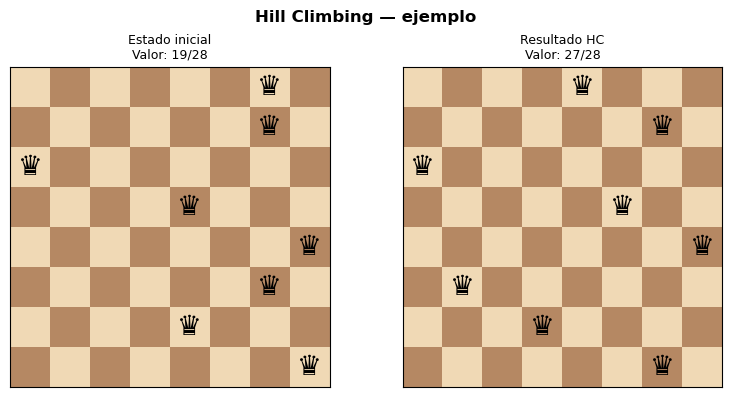

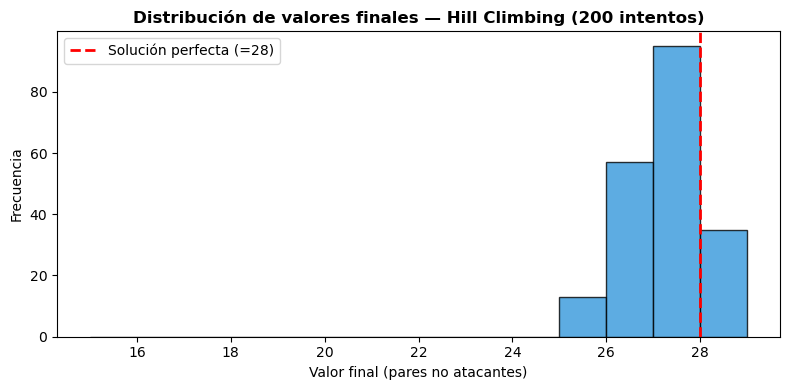

In [4]:
random.seed(42)

# Ejecutar Hill Climbing 20 veces desde estados aleatorios
hc_values = []
hc_solutions = 0
N_TRIALS = 200

for _ in range(N_TRIALS):
    init = tuple(random.randint(0, N-1) for _ in range(N))
    problem = NQueensProblem(initial_state=init)
    result = hill_climbing(problem)
    val = problem.value(result.state)
    hc_values.append(val)
    if val == MAX_VALUE:
        hc_solutions += 1

print(f"Hill Climbing — {N_TRIALS} intentos desde estados aleatorios:")
print(f"  Valor promedio : {np.mean(hc_values):.2f} / {MAX_VALUE}")
print(f"  Valor máximo   : {max(hc_values)}")
print(f"  Valor mínimo   : {min(hc_values)}")
print(f"  Soluciones perfectas (valor={MAX_VALUE}): {hc_solutions} ({hc_solutions/N_TRIALS*100:.1f}%)")

# Mostrar un ejemplo de resultado
random.seed(0)
init_ex = tuple(random.randint(0, N-1) for _ in range(N))
result_ex = hill_climbing(NQueensProblem(initial_state=init_ex))
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_board(init_ex, axes[0], "Estado inicial")
draw_board(result_ex.state, axes[1], "Resultado HC")
plt.suptitle("Hill Climbing — ejemplo", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Histograma de valores finales
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hc_values, bins=range(15, MAX_VALUE+2), color='#3498db', alpha=0.8, edgecolor='black')
ax.axvline(MAX_VALUE, color='red', linestyle='--', linewidth=2, label=f'Solución perfecta (={MAX_VALUE})')
ax.set_xlabel('Valor final (pares no atacantes)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de valores finales — Hill Climbing ({N_TRIALS} intentos)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 🔁 Paso 4: Hill Climbing con Reinicios Aleatorios

Si Hill Climbing queda atrapado, **recomienza desde un estado aleatorio**. Con suficientes reinicios, la probabilidad de encontrar una solución óptima crece.

Si la probabilidad de éxito por intento es $p$, entonces:

$$P(\text{éxito en } k \text{ intentos}) = 1 - (1-p)^k$$

 Reinicios  Éxito %
         1     26.0
         5     52.0
        10     78.0
        20     92.0
        50    100.0
       100    100.0

Ejemplo con 20 reinicios → valor: 28/28 — ✅ Solución perfecta


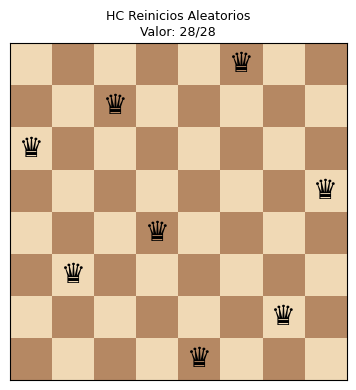

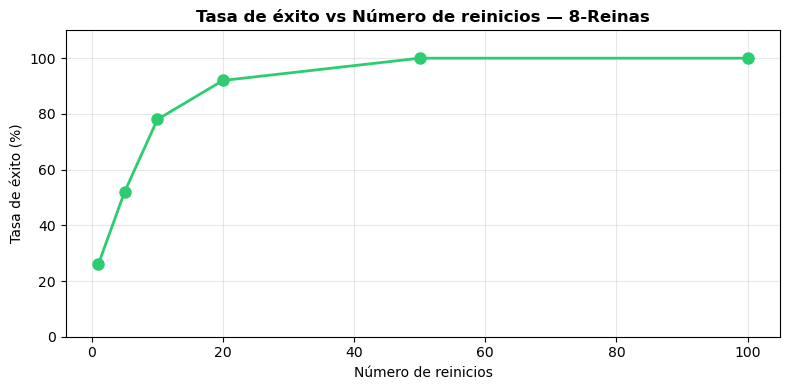

In [7]:
random.seed(42)

# Ejecutar HC con reinicios — distintos límites de reinicios
restarts_list = [1, 5, 10, 20, 50, 100]
results_hcrr = []

for restarts in restarts_list:
    solutions = 0
    REPS = 50  # repeticiones por configuración
    for _ in range(REPS):
        init = tuple(random.randint(0, N-1) for _ in range(N))
        problem = NQueensProblem(initial_state=init)
        result = hill_climbing_random_restarts(problem, restarts_limit=restarts)
        if problem.value(result.state) == MAX_VALUE:
            solutions += 1
    results_hcrr.append({'Reinicios': restarts, 'Éxito %': solutions / REPS * 100})

df_hcrr = pd.DataFrame(results_hcrr)
print(df_hcrr.to_string(index=False))

# Un ejemplo concreto con 20 reinicios
random.seed(5)
init_hcrr = tuple(random.randint(0, N-1) for _ in range(N))
problem_hcrr = NQueensProblem(initial_state=init_hcrr)
result_hcrr = hill_climbing_random_restarts(problem_hcrr, restarts_limit=20)
val_hcrr = problem_hcrr.value(result_hcrr.state)
print(f"\nEjemplo con 20 reinicios → valor: {val_hcrr}/{MAX_VALUE} — {'✅ Solución perfecta' if val_hcrr == MAX_VALUE else '⚠️  Óptimo local'}")

if val_hcrr == MAX_VALUE:
    fig, ax = plt.subplots(figsize=(4, 4))
    draw_board(result_hcrr.state, ax, "HC Reinicios Aleatorios")
    plt.tight_layout()
    plt.show()

# Gráfico de tasa de éxito
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_hcrr['Reinicios'], df_hcrr['Éxito %'], 'o-', color='#2ecc71', linewidth=2, markersize=8)
ax.set_xlabel('Número de reinicios')
ax.set_ylabel('Tasa de éxito (%)')
ax.set_title('Tasa de éxito vs Número de reinicios — 8-Reinas', fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🌡️ Paso 5: Simulated Annealing

Inspirado en el proceso de **recocido metalúrgico**: al principio acepta movimientos peores con alta probabilidad (temperatura alta); a medida que se "enfría", se vuelve más selectivo.

Probabilidad de aceptar un estado peor:

$$P(\text{aceptar}) = e^{-\Delta E / T}$$

donde $\Delta E = \text{valor actual} - \text{valor vecino}$ y $T$ decrece con el tiempo.

In [10]:
from simpleai.search.local import exp_schedule

random.seed(42)

# Ejecutar SA varias veces
sa_values = []
sa_solutions = 0

for _ in range(N_TRIALS):
    init = tuple(random.randint(0, N-1) for _ in range(N))
    problem = NQueensProblem(initial_state=init)
    result = simulated_annealing(problem)
    val = problem.value(result.state)
    sa_values.append(val)
    if val == MAX_VALUE:
        sa_solutions += 1

print(f"Simulated Annealing — {N_TRIALS} intentos:")
print(f"  Valor promedio : {np.mean(sa_values):.2f} / {MAX_VALUE}")
print(f"  Soluciones perfectas: {sa_solutions} ({sa_solutions/N_TRIALS*100:.1f}%)")

# Calendario de temperatura
schedule = exp_schedule(k=20, lam=0.005, limit=1000)
temps = [schedule(t) for t in range(1000)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Temperatura vs tiempo
axes[0].plot(temps, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Paso de tiempo')
axes[0].set_ylabel('Temperatura')
axes[0].set_title('Calendario de temperatura exponencial', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Probabilidad de aceptar diferentes ΔE
T_vals = np.linspace(0.1, 20, 200)
for delta_e in [1, 3, 5]:
    probs = np.exp(-delta_e / T_vals)
    axes[1].plot(T_vals, probs, linewidth=2, label=f'ΔE = {delta_e}')
axes[1].set_xlabel('Temperatura T')
axes[1].set_ylabel('Probabilidad de aceptar')
axes[1].set_title('P(aceptar peor solución) = e^(-ΔE/T)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ejemplo de tablero con SA
random.seed(99)
init_sa = tuple(random.randint(0, N-1) for _ in range(N))
result_sa = simulated_annealing(NQueensProblem(initial_state=init_sa))
val_sa = NQueensProblem().value(result_sa.state)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_board(init_sa, axes[0], "Estado inicial")
draw_board(result_sa.state, axes[1], "Resultado SA")
plt.suptitle("Simulated Annealing — ejemplo", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ImportError: cannot import name 'exp_schedule' from 'simpleai.search.local' (/home/cripac/miniconda3/envs/ai/lib/python3.12/site-packages/simpleai/search/local.py)

## 🧬 Paso 6: Algoritmo Genético

Mantiene una **población** de estados y los combina mediante:
1. **Selección**: los individuos más aptos tienen más probabilidad de reproducirse.
2. **Cruce (crossover)**: combina dos individuos para crear un descendiente.
3. **Mutación**: introduce cambios aleatorios para mantener diversidad.

Con `simpleai`: `genetic(problem, population_size, mutation_chance, iterations_limit)`

=== Operadores Genéticos ===
Padre 1 : (0, 3, 5, 1, 6, 4, 2, 7)   valor=25
Padre 2 : (7, 2, 4, 6, 1, 3, 5, 0)   valor=27
Hijo    : (0, 3, 5, 1, 6, 4, 5, 0)   valor=22
Mutado  : (0, 0, 5, 1, 6, 4, 5, 0)   valor=20

Algoritmo Genético — 200 corridas:
  Valor promedio : 25.91 / 28
  Soluciones perfectas: 6 (3.0%)

Ejemplo AG → estado: (2, 5, 0, 1, 7, 4, 6, 3), valor: 26/28


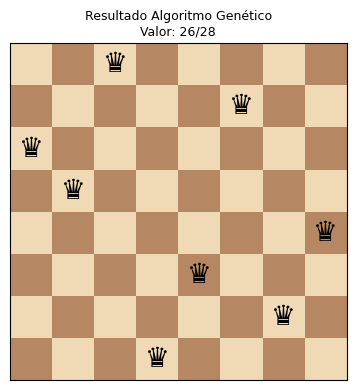

In [9]:
random.seed(42)

# Operadores genéticos definidos en NQueensProblem:
# crossover: cruce de un punto
# mutate: cambiar columna de una reina aleatoria
# Demostración
s1 = (0, 3, 5, 1, 6, 4, 2, 7)
s2 = (7, 2, 4, 6, 1, 3, 5, 0)
prob_demo = NQueensProblem()
child = prob_demo.crossover(s1, s2)
mutated = prob_demo.mutate(child)
print("=== Operadores Genéticos ===")
print(f"Padre 1 : {s1}   valor={prob_demo.value(s1)}")
print(f"Padre 2 : {s2}   valor={prob_demo.value(s2)}")
print(f"Hijo    : {child}   valor={prob_demo.value(child)}")
print(f"Mutado  : {mutated}   valor={prob_demo.value(mutated)}")
print()

# Ejecutar AG varias veces
ga_values = []
ga_solutions = 0

for trial in range(N_TRIALS):
    init = tuple(random.randint(0, N-1) for _ in range(N))
    problem = NQueensProblem(initial_state=init)
    result = genetic(
        problem,
        population_size=50,
        mutation_chance=0.15,
        iterations_limit=500
    )
    val = problem.value(result.state)
    ga_values.append(val)
    if val == MAX_VALUE:
        ga_solutions += 1

print(f"Algoritmo Genético — {N_TRIALS} corridas:")
print(f"  Valor promedio : {np.mean(ga_values):.2f} / {MAX_VALUE}")
print(f"  Soluciones perfectas: {ga_solutions} ({ga_solutions/N_TRIALS*100:.1f}%)")

# Ejemplo de solución del AG
random.seed(123)
init_ga = tuple(random.randint(0, N-1) for _ in range(N))
problem_ga = NQueensProblem(initial_state=init_ga)
result_ga = genetic(problem_ga, population_size=100, mutation_chance=0.15, iterations_limit=1000)
val_ga = problem_ga.value(result_ga.state)
print(f"\nEjemplo AG → estado: {result_ga.state}, valor: {val_ga}/{MAX_VALUE}")
fig, ax = plt.subplots(figsize=(4, 4))
draw_board(result_ga.state, ax, "Resultado Algoritmo Genético")
plt.tight_layout()
plt.show()

## 📊 Paso 7: Comparativa de métodos

In [ ]:
# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histograma de valores finales ---
bins = range(15, MAX_VALUE + 2)
axes[0].hist(hc_values, bins=bins, alpha=0.65, label='Hill Climbing', color='#3498db')
axes[0].hist(sa_values, bins=bins, alpha=0.65, label='Simulated Annealing', color='#e67e22')
axes[0].hist(ga_values, bins=bins, alpha=0.65, label='Algoritmo Genético', color='#9b59b6')
axes[0].axvline(MAX_VALUE, color='red', linestyle='--', linewidth=2, label=f'Óptimo ({MAX_VALUE})')
axes[0].set_xlabel('Valor final')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de valores finales', fontweight='bold')
axes[0].legend()

# --- Barras de tasa de éxito ---
metodos = ['Hill Climbing', 'SA', 'AG']
tasas = [
    hc_solutions / N_TRIALS * 100,
    sa_solutions / N_TRIALS * 100,
    ga_solutions / N_TRIALS * 100,
]
colores = ['#3498db', '#e67e22', '#9b59b6']
bars = axes[1].bar(metodos, tasas, color=colores, alpha=0.85, edgecolor='black')
for bar, tasa in zip(bars, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{tasa:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tasa de éxito (%)')
axes[1].set_ylim(0, 115)
axes[1].set_title(f'Tasa de éxito en {N_TRIALS} intentos (8-Reinas)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa de Algoritmos de Búsqueda Local — 8-Reinas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
df_comp = pd.DataFrame({
    'Algoritmo': ['Hill Climbing', 'Simulated Annealing', 'Algoritmo Genético'],
    'Valor promedio': [f"{np.mean(hc_values):.2f}", f"{np.mean(sa_values):.2f}", f"{np.mean(ga_values):.2f}"],
    'Tasa de éxito': [f"{hc_solutions/N_TRIALS*100:.1f}%", f"{sa_solutions/N_TRIALS*100:.1f}%", f"{ga_solutions/N_TRIALS*100:.1f}%"],
    'Escapa óptimos locales': ['No', 'Sí (probabilístico)', 'Sí (diversidad)'],
})
display(df_comp)

## 🎓 Resumen y Conclusiones

### Puntos clave

1. **Hill Climbing** es rápido pero queda atrapado en óptimos locales; su tasa de éxito en 8-Reinas desde inicio aleatorio es baja.
2. **Reinicios aleatorios** mejoran la tasa de éxito significativamente con un costo computacional controlado. La mejora sigue la curva $1-(1-p)^k$.
3. **Simulated Annealing** escapa de óptimos locales aceptando soluciones peores con probabilidad decreciente $e^{-\Delta E/T}$; es sensible al calendario de temperatura.
4. **Algoritmos Genéticos** mantienen diversidad poblacional y combinan soluciones buenas; son más lentos pero robustos ante problemas con gran espacio de búsqueda.
5. Ningún método domina en todos los escenarios: la elección depende del problema, el tiempo disponible y la tolerancia a soluciones subóptimas.

### 🚀 ¿Qué sigue?

- **Búsqueda de haz local** (Beam Search): mantiene $k$ estados simultáneamente.
- **Optimización por enjambre de partículas (PSO)**: inspirada en bandadas de pájaros.
- **Optimización por colonia de hormigas (ACO)**: grafos ponderados, TSP.
- **Aprendizaje por refuerzo**: cuando el entorno es desconocido y se aprende a través de la interacción.

### 📚 Referencias

- Russell & Norvig — *Artificial Intelligence: A Modern Approach* (4th ed.), Cap. 4.
- Kirkpatrick, S. et al. (1983). *Optimization by Simulated Annealing*. Science, 220(4598), 671–680.
- Holland, J.H. (1992). *Adaptation in Natural and Artificial Systems*. MIT Press.
- Documentación simpleai: https://simpleai.readthedocs.io

---

*© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER*  
[![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/4.0/88x31.png)](https://creativecommons.org/licenses/by-sa/4.0/)